In [1]:
import pandas as pd
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier, 
    ExtraTreesClassifier,
    BaggingClassifier,
    VotingClassifier
)
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import (
    LogisticRegression, 
    SGDClassifier, 
    Perceptron,
    PassiveAggressiveClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import pickle
from xgboost import XGBClassifier

In [2]:
# df = pd.read_csv("./malicious_phish_preprocessed.csv")

In [3]:
# import matplotlib.pyplot as plt
# import os

# # Four types: benign, phishing, defacement and malware
# label_counts = df['type'].value_counts()

# print(label_counts)

# plt.figure(figsize=(10, 6))
# plt.pie(label_counts.values, labels=["benign", "defacement", "phishing", "malware"], autopct='%1.1f%%')
# plt.title('Distribution of Phishing URLs')
# plt.savefig(os.path.join("./figs", "phishing_types_distribution.png"), bbox_inches='tight')
# plt.show()

# del label_counts

In [4]:
import pandas as pd

df = pd.read_csv("./malicious_phish_preprocessed.csv")
# def numeric_labels(x):
#     label_map = {
#         "benign": 0,
#         "defacement": 1,
#         "phishing": 1,
#         "malware": 1
#     }

#     typ = x["type"]

#     return label_map[typ]

# df["label"] = df.apply(numeric_labels, axis=1)
# df["label"]
# df = df.drop(columns=["", "Unnamed: 0.1"], errors="ignore")
# df.to_csv("./malicious_phish_preprocessed.csv", index=False)

In [5]:
X = df.drop(columns=["Unnamed: 0", "url", "type", "label"], errors="ignore")
y = df["label"]
del df

In [6]:
import numpy as np

X = pd.get_dummies(X, columns=["tld"], drop_first=True)

from sklearn.preprocessing import LabelEncoder

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

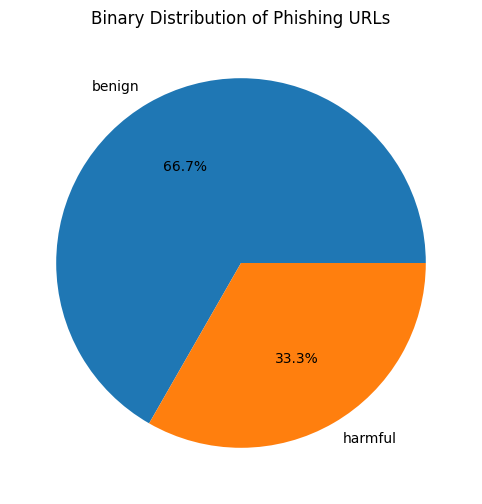

In [8]:
import matplotlib.pyplot as plt
import os

unique, counts = np.unique(y, return_counts=True)

counter = dict(zip(unique, counts))

plt.figure(figsize=(10, 6))
plt.pie(counter.values(), labels=["benign", "harmful"], autopct='%1.1f%%')
plt.title('Binary Distribution of Phishing URLs')
plt.savefig(os.path.join("./figs", "phishing_types_distribution.png"), bbox_inches='tight')
plt.show()

del unique, counts, counter

In [9]:
from sklearn.base import BaseEstimator
from sklearn.metrics import roc_curve

def evaluate_and_plot_proba(model:BaseEstimator, save_plot=True, save_folder="./figs/"):
    if isinstance(model, (
        KNeighborsClassifier, 
        AdaBoostClassifier, 
        LogisticRegression,
        BernoulliNB,
        DecisionTreeClassifier,
        RandomForestClassifier,
        ExtraTreesClassifier,
        MultinomialNB,
        BernoulliNB,
        BaggingClassifier,
        XGBClassifier
        )):

        y_proba = model.predict_proba(X_test)[:, 1]

        fpr, tpr, thresholds = roc_curve(y_test, y_proba)

        plt.figure(figsize=(10, 6))
        plt.plot(fpr, tpr, color='blue', label=f'ROC curve for {model.__class__.__name__}')
        plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
        plt.title(f'ROC Curve for {model.__class__.__name__}')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        if save_plot:
            plt.savefig(os.path.join(save_folder, f"{model.__class__.__name__}_roc_curve.jpg"))
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print("Model does not support probability prediction. Skipping ROC curve plotting.")

In [10]:
# vt = VotingClassifier([
#     ("rf", RandomForestClassifier(n_jobs=4, random_state=42)),
#     ("ext", ExtraTreesClassifier(n_jobs=4, random_state=42)),
#     ("bg", BaggingClassifier(n_jobs=4, random_state=42))
# ], n_jobs=3, voting="soft")
# vt.fit(X_train, y_train)
# with open("./models/voting_classifier.pkl", "wb") as f:
#     pickle.dump(vt, f)

In [11]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
with open("./models/logistic_regression_url.pkl", "wb") as f:
    pickle.dump(lr, f)

e:\Python Tests\AI\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
with open("./models/logistic_regression_url.pkl", "rb") as f:
    lr = pickle.load(f)

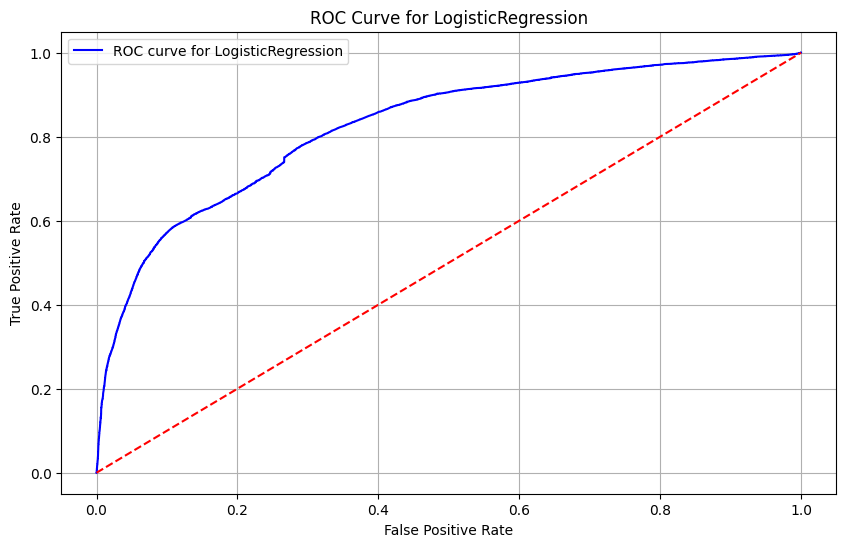

              precision    recall  f1-score   support

           0     0.8056    0.9072    0.8534     63512
           1     0.7498    0.5596    0.6409     31572

    accuracy                         0.7918     95084
   macro avg     0.7777    0.7334    0.7471     95084
weighted avg     0.7871    0.7918    0.7828     95084



In [13]:
evaluate_and_plot_proba(lr)

y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred, digits=4))

del lr

In [14]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)
with open("./models/ada_boost_url.pkl", "wb") as f:
    pickle.dump(ada, f)

In [16]:
with open("./models/ada_boost_url.pkl", "rb") as f:
    ada = pickle.load(f)

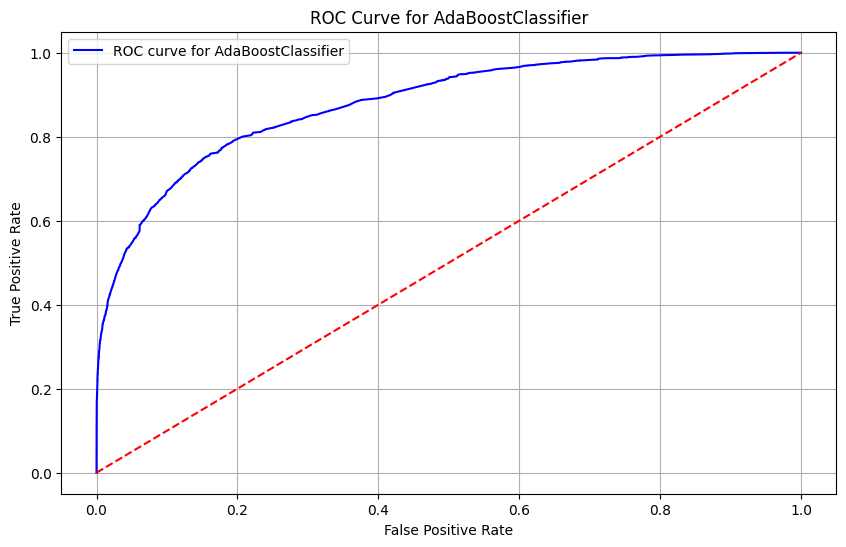

              precision    recall  f1-score   support

           0     0.8272    0.9287    0.8750     63512
           1     0.8096    0.6097    0.6956     31572

    accuracy                         0.8228     95084
   macro avg     0.8184    0.7692    0.7853     95084
weighted avg     0.8214    0.8228    0.8155     95084



In [17]:
evaluate_and_plot_proba(ada)

y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del ada

In [18]:
bernb = BernoulliNB()
bernb.fit(X_train, y_train)
with open("./models/bernoulli_nb_url.pkl", "wb") as f:
    pickle.dump(bernb, f)

In [19]:
with open("./models/bernoulli_nb_url.pkl", "rb") as f:
    bernb = pickle.load(f)

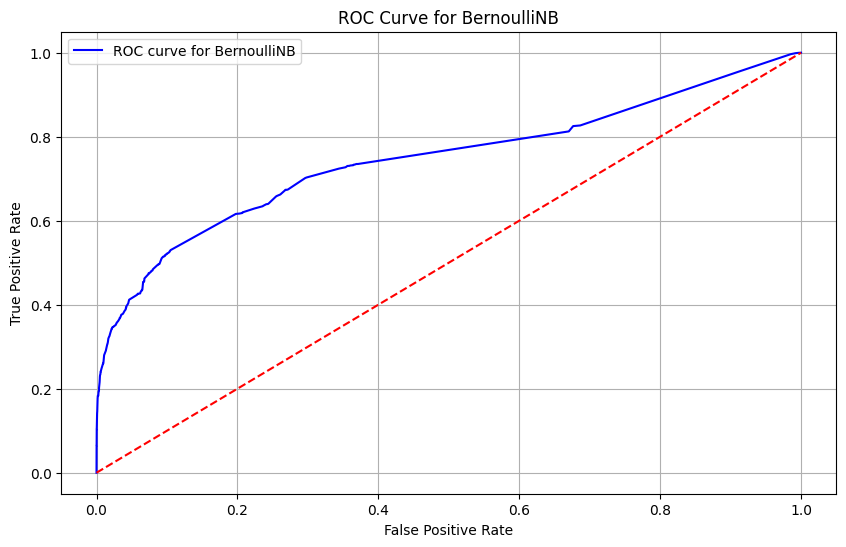

              precision    recall  f1-score   support

           0     0.7847    0.9107    0.8430     63512
           1     0.7346    0.4974    0.5932     31572

    accuracy                         0.7735     95084
   macro avg     0.7597    0.7041    0.7181     95084
weighted avg     0.7681    0.7735    0.7601     95084



In [20]:
evaluate_and_plot_proba(bernb)

y_pred = bernb.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del bernb

In [21]:
mulnb = MultinomialNB()
mulnb.fit(X_train, y_train)
with open("./models/multinomial_nb_url.pkl", "wb") as f:
    pickle.dump(mulnb, f)

In [22]:
with open("./models/multinomial_nb_url.pkl", "rb") as f:
    mulnb = pickle.load(f)

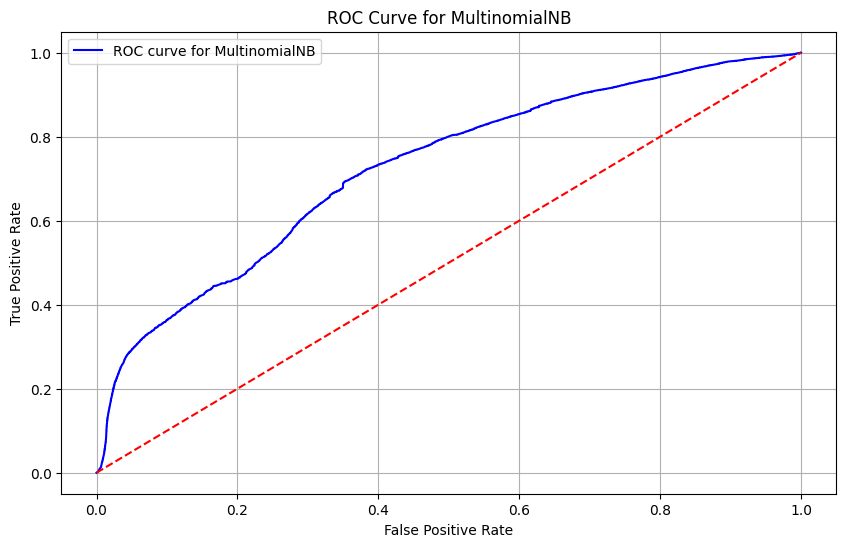

              precision    recall  f1-score   support

           0     0.7961    0.6703    0.7278     63512
           1     0.4967    0.6546    0.5648     31572

    accuracy                         0.6651     95084
   macro avg     0.6464    0.6624    0.6463     95084
weighted avg     0.6967    0.6651    0.6737     95084



In [23]:
evaluate_and_plot_proba(mulnb)
y_pred = mulnb.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del mulnb

In [24]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
with open("./models/decision_tree_url.pkl", "wb") as f:
    pickle.dump(dt, f)

In [25]:
with open("./models/decision_tree_url.pkl", "rb") as f:
    dt = pickle.load(f)

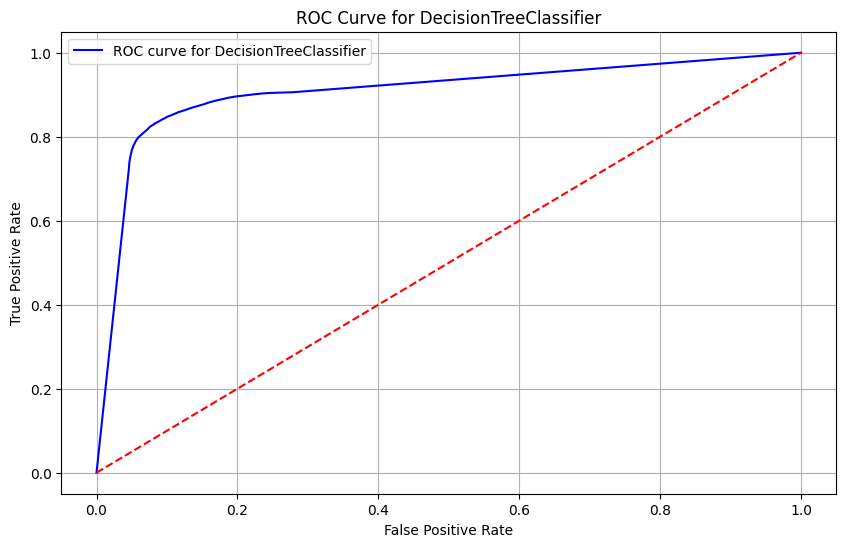

              precision    recall  f1-score   support

           0     0.9045    0.9395    0.9217     63512
           1     0.8680    0.8005    0.8329     31572

    accuracy                         0.8933     95084
   macro avg     0.8863    0.8700    0.8773     95084
weighted avg     0.8924    0.8933    0.8922     95084



In [26]:
evaluate_and_plot_proba(dt)
y_pred = dt.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del dt

In [27]:
rf = RandomForestClassifier(random_state=42, n_jobs=4)
rf.fit(X_train, y_train)
with open("./models/random_forest_url.pkl", "wb") as f:
    pickle.dump(rf, f)

In [28]:
with open("./models/random_forest_url.pkl", "rb") as f:
    rf = pickle.load(f)

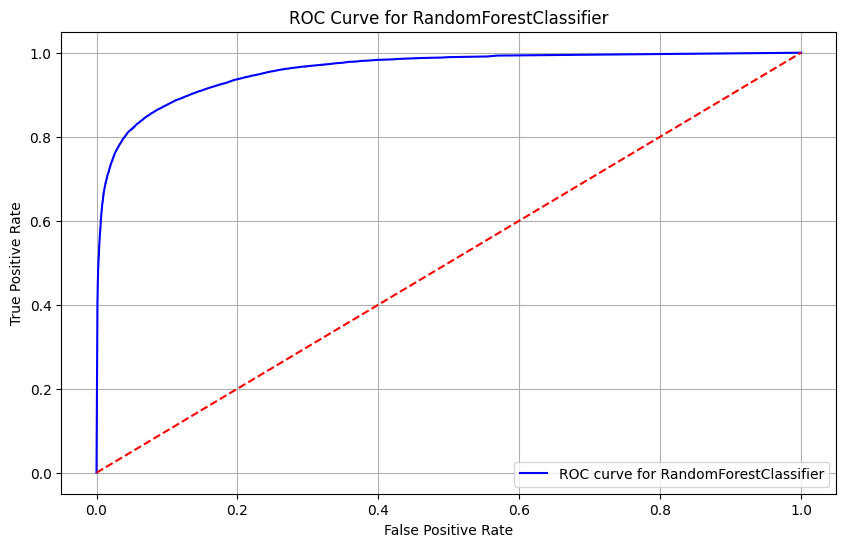

              precision    recall  f1-score   support

           0     0.9119    0.9526    0.9318     63512
           1     0.8953    0.8149    0.8532     31572

    accuracy                         0.9069     95084
   macro avg     0.9036    0.8837    0.8925     95084
weighted avg     0.9064    0.9069    0.9057     95084



In [29]:
evaluate_and_plot_proba(rf)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del rf

In [30]:
ext = ExtraTreesClassifier(random_state=42, n_jobs=4)
ext.fit(X_train, y_train)
with open("./models/extra_trees_url.pkl", "wb") as f:
    pickle.dump(ext, f)

In [31]:
with open("./models/extra_trees_url.pkl", "rb") as f:
    ext = pickle.load(f)

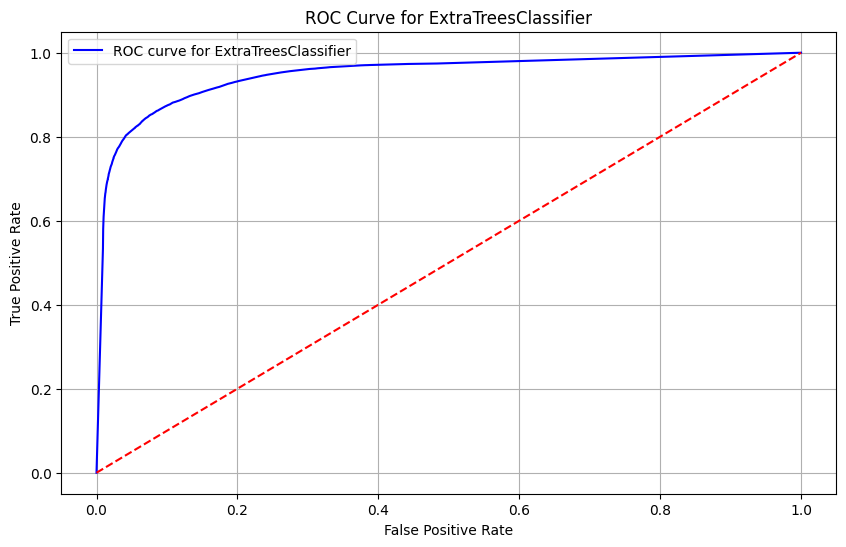

              precision    recall  f1-score   support

           0     0.9093    0.9547    0.9314     63512
           1     0.8987    0.8083    0.8511     31572

    accuracy                         0.9061     95084
   macro avg     0.9040    0.8815    0.8913     95084
weighted avg     0.9058    0.9061    0.9048     95084



In [32]:
evaluate_and_plot_proba(ext)
y_pred = ext.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del ext

In [33]:
bag = BaggingClassifier(random_state=42, n_jobs=4)
bag.fit(X_train, y_train)
with open("./models/bagging_url.pkl", "wb") as f:
    pickle.dump(bag, f)

In [34]:
with open("./models/bagging_url.pkl", "rb") as f:
    bag = pickle.load(f)

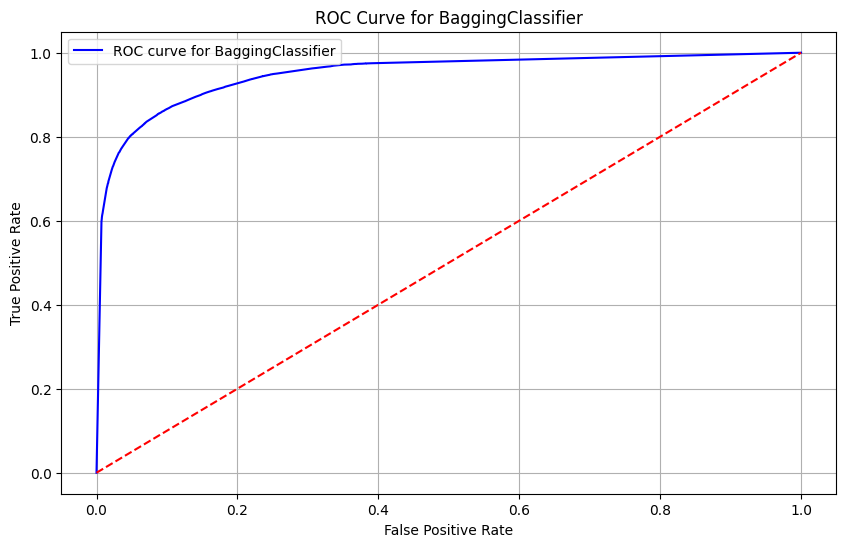

              precision    recall  f1-score   support

           0     0.9079    0.9489    0.9280     63512
           1     0.8870    0.8063    0.8448     31572

    accuracy                         0.9016     95084
   macro avg     0.8975    0.8776    0.8864     95084
weighted avg     0.9010    0.9016    0.9003     95084



In [35]:
evaluate_and_plot_proba(bag)
y_pred = bag.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del bag

In [ ]:
per = Perceptron(random_state=42, n_jobs=4)
per.fit(X_train, y_train)
with open("./models/perceptron_url.pkl", "wb") as f:
    pickle.dump(per, f)

In [37]:
with open("./models/perceptron_url.pkl", "rb") as f:
    per = pickle.load(f)

In [38]:
evaluate_and_plot_proba(per)
y_pred = per.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del per

Model does not support probability prediction. Skipping ROC curve plotting.
              precision    recall  f1-score   support

           0     0.6783    0.9997    0.8082     63512
           1     0.9864    0.0461    0.0880     31572

    accuracy                         0.6830     95084
   macro avg     0.8323    0.5229    0.4481     95084
weighted avg     0.7806    0.6830    0.5691     95084



In [39]:
pasag = PassiveAggressiveClassifier(random_state=42, n_jobs=4)
pasag.fit(X_train, y_train)
with open("./models/passive_aggressive_url.pkl", "wb") as f:
    pickle.dump(pasag, f)

In [40]:
with open("./models/passive_aggressive_url.pkl", "rb") as f:
    pasag = pickle.load(f)

In [41]:
evaluate_and_plot_proba(pasag)
y_pred = pasag.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del pasag

Model does not support probability prediction. Skipping ROC curve plotting.
              precision    recall  f1-score   support

           0     0.7696    0.9545    0.8521     63512
           1     0.8228    0.4251    0.5605     31572

    accuracy                         0.7787     95084
   macro avg     0.7962    0.6898    0.7063     95084
weighted avg     0.7872    0.7787    0.7553     95084



In [42]:
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
with open("./models/linear_svc_url.pkl", "wb") as f:
    pickle.dump(svm, f)

e:\Python Tests\AI\.venv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [43]:
with open("./models/linear_svc_url.pkl", "rb") as f:
    svm = pickle.load(f)

In [44]:
evaluate_and_plot_proba(svm)
y_pred = svm.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del svm

Model does not support probability prediction. Skipping ROC curve plotting.
              precision    recall  f1-score   support

           0     0.7792    0.9466    0.8548     63512
           1     0.8108    0.4602    0.5872     31572

    accuracy                         0.7851     95084
   macro avg     0.7950    0.7034    0.7210     95084
weighted avg     0.7897    0.7851    0.7659     95084



In [45]:
sgd = SGDClassifier(random_state=42, n_jobs=4)
sgd.fit(X_train, y_train)
with open("./models/sgd_url.pkl", "wb") as f:
    pickle.dump(sgd, f)

In [46]:
with open("./models/sgd_url.pkl", "rb") as f:
    sgd = pickle.load(f)

In [47]:
evaluate_and_plot_proba(sgd)
y_pred = sgd.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del sgd

Model does not support probability prediction. Skipping ROC curve plotting.
              precision    recall  f1-score   support

           0     0.7871    0.0254    0.0492     63512
           1     0.3347    0.9862    0.4997     31572

    accuracy                         0.3444     95084
   macro avg     0.5609    0.5058    0.2745     95084
weighted avg     0.6369    0.3444    0.1988     95084



In [48]:
knn = KNeighborsClassifier(n_jobs=4)
knn.fit(X_train, y_train)
with open("./models/knn_url.pkl", "wb") as f:
    pickle.dump(knn, f)

In [49]:
with open("./models/knn_url.pkl", "rb") as f:
    knn = pickle.load(f)

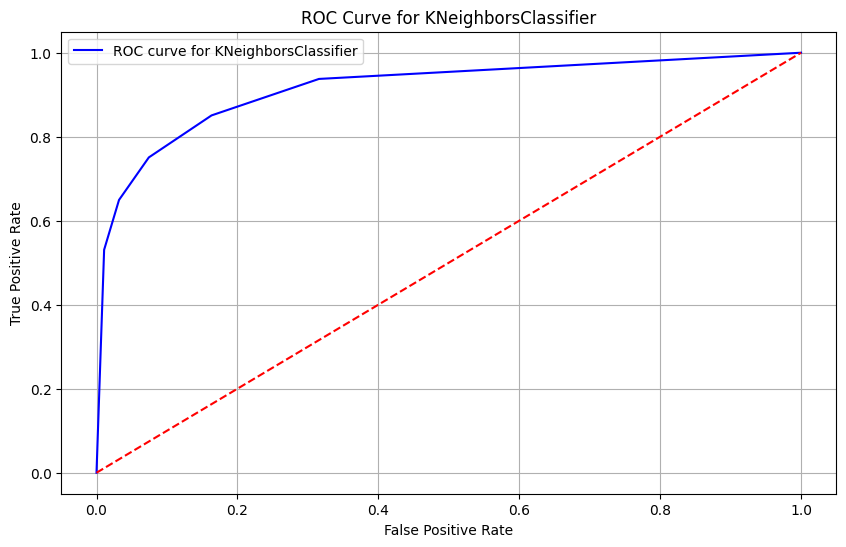

              precision    recall  f1-score   support

           0     0.8819    0.9257    0.9033     63512
           1     0.8340    0.7507    0.7902     31572

    accuracy                         0.8676     95084
   macro avg     0.8580    0.8382    0.8467     95084
weighted avg     0.8660    0.8676    0.8657     95084



In [50]:
evaluate_and_plot_proba(knn)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del knn

In [51]:
X_train = X_train.drop(columns=[
    'tld_2å~î\x05ä³7\x13g®x\x12\x9búä\x914²k\x07\x8bxâ`õ',
     "tld_7õú x\x1d\x0f'\x98}\x97ø\x814~æê¸a(_à\x7f",
     'tld__\x15\x01ãö%\x94p\x06bm\x0e',
     'tld_c³\x99^\x10\x91c·ù*%\x84yö\x96\x19g²2oê',
     'tld_t|jöäæ°!nqä\x8c\xad\x99þ\x9fÿ\x832á\x81\x1dº»sr\x04\x1dònú\x17z\x18b\x9dü\x9a\x98¤òy\x07\x1asõqµ',
     'tld_xn--p1ai',
     'tld_\x92\x96*\x8d',
 'tld_á>v>4z¢¶mù2<¯loâ\x8a¿3\x061\x08è',
 "tld_é¾¾t\x1e\x0e`(+}^«\x9d´i\x83\\\x83'f\x894\x18æ \x81\x16}cjñ",
 "Unnamed: 0.1"
], errors="ignore")
X_test = X_test.drop(columns=[
    'tld_2å~î\x05ä³7\x13g®x\x12\x9búä\x914²k\x07\x8bxâ`õ',
     "tld_7õú x\x1d\x0f'\x98}\x97ø\x814~æê¸a(_à\x7f",
     'tld__\x15\x01ãö%\x94p\x06bm\x0e',
     'tld_c³\x99^\x10\x91c·ù*%\x84yö\x96\x19g²2oê',
     'tld_t|jöäæ°!nqä\x8c\xad\x99þ\x9fÿ\x832á\x81\x1dº»sr\x04\x1dònú\x17z\x18b\x9dü\x9a\x98¤òy\x07\x1asõqµ',
     'tld_xn--p1ai',
     'tld_\x92\x96*\x8d',
 'tld_á>v>4z¢¶mù2<¯loâ\x8a¿3\x061\x08è',
 "tld_é¾¾t\x1e\x0e`(+}^«\x9d´i\x83\\\x83'f\x894\x18æ \x81\x16}cjñ",
 "Unnamed: 0.1"
], errors="ignore")
list(X_train.columns)

['url_length',
 'hostname_length',
 'path_length',
 'num_dots',
 'num_slashes',
 'num_digits',
 'num_special_chars',
 'has_https',
 'has_ip',
 'has_port',
 'has_at_symbol',
 'has_query',
 'num_params',
 'domain_in_path',
 'tld_0',
 'tld_1',
 'tld_10',
 'tld_100',
 'tld_101',
 'tld_102',
 'tld_103',
 'tld_104',
 'tld_105',
 'tld_106',
 'tld_107',
 'tld_108',
 'tld_109',
 'tld_11',
 'tld_110',
 'tld_111',
 'tld_112',
 'tld_113',
 'tld_114',
 'tld_115',
 'tld_116',
 'tld_117',
 'tld_118',
 'tld_119',
 'tld_12',
 'tld_120',
 'tld_121',
 'tld_122',
 'tld_123',
 'tld_124',
 'tld_125',
 'tld_126',
 'tld_127',
 'tld_128',
 'tld_129',
 'tld_13',
 'tld_130',
 'tld_131',
 'tld_132',
 'tld_133',
 'tld_134',
 'tld_135',
 'tld_136',
 'tld_137',
 'tld_138',
 'tld_139',
 'tld_14',
 'tld_140',
 'tld_141',
 'tld_142',
 'tld_143',
 'tld_144',
 'tld_145',
 'tld_146',
 'tld_147',
 'tld_148',
 'tld_149',
 'tld_15',
 'tld_150',
 'tld_151',
 'tld_152',
 'tld_153',
 'tld_154',
 'tld_155',
 'tld_156',
 'tld_157

In [52]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [53]:
with open("./models/xgb_url.pkl", "wb") as f:
    pickle.dump(xgb, f)

In [54]:
with open("./models/xgb_url.pkl", "rb") as f:
    xgb = pickle.load(f)

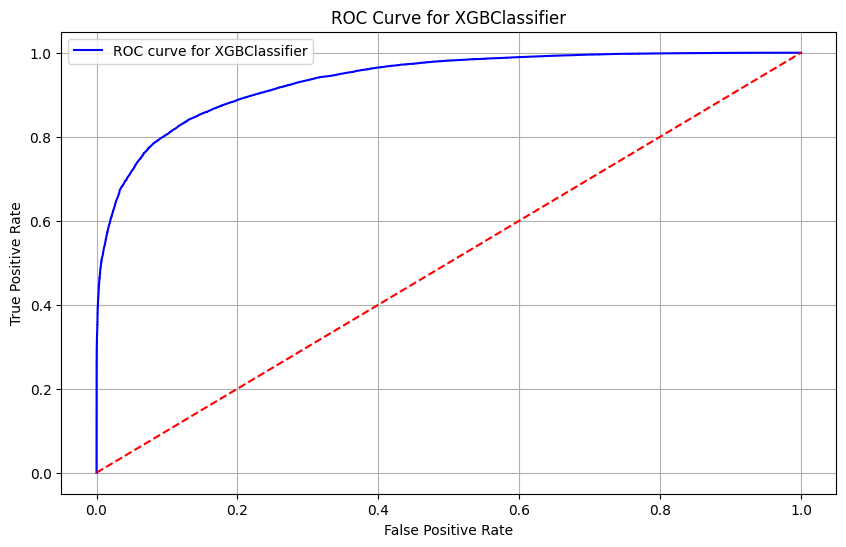

              precision    recall  f1-score   support

           0     0.8777    0.9438    0.9096     63512
           1     0.8668    0.7356    0.7958     31572

    accuracy                         0.8746     95084
   macro avg     0.8723    0.8397    0.8527     95084
weighted avg     0.8741    0.8746    0.8718     95084



In [55]:
evaluate_and_plot_proba(xgb)
y_pred = xgb.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))
del xgb